# IQ generation: phase from a real series, spectrum from a wireless channel

A complex baseband fading coefficient $z[t] = I[t] + j Q[t]$ is **not** an analytic signal. Its Doppler spectrum is two-sided, and $I$ and $Q$ are typically uncorrelated. An analytic pair (one-sided spectrum, $Q \approx \mathcal{H}\{I\}$) is a different, equally legitimate target. Stacking a Hilbert transform, a one-sided PSD match, and a hard low-pass filter cannot produce both: the three steps overwrite each other.

`IQSimulator` therefore splits the two goals and transfers **two different things** from two different sources:

1. **Phase** comes from a real stimulus $x[t]$ — either a series you provide, or two independent ARMA channels drawn by `AutoregressiveMovingAverage` (the same generator as `examples/excitation/arma.ipynb`).
2. **Spectrum shape** comes from a reference wireless channel: the mean windowed periodogram $P[k]$ of DeepMIMO CSI snapshots.

This notebook follows that pipeline: mathematical sketch, default ARMA generation, a user-provided stimulus, then the effect of `mode`, `match_mix`, vehicle speed, and the optional low-pass stage. All figures use `plot_iq_series` / `plot_iq_analysis`.

## Algorithm

Let $x[t]$ be a real series of length at least the requested IQ length $L$. A padded window is z-scored (and optionally low-passed). The Hilbert transform of that *padded* window is cropped back to $L$, giving a complex seed

$$
z[t] = I[t] + j\, Q[t], \qquad Q[t] \approx \mathcal{H}\{I\}[t]
$$
on the support of the window. After Hilbert the negative-frequency half of $Z[k] = \mathrm{FFT}(z)$ is essentially zero. Weak bins therefore receive interpolated unwrapped phase (`_infill_phase`); otherwise a two-sided magnitude match would be forced into a conjugate-symmetric, i.e. real-valued, phase.

Magnitudes are then blended toward the reference periodogram:

$$
|Z'[k]| = (1-m)\,|Z[k]| + m\,\sqrt{P[k]}, \qquad m \in [0,1].
$$

- **`mode="baseband"` (default).** Negative frequencies are **kept**. $P[k]$ is the two-sided Doppler spectrum of a fading coefficient. $I$ and $Q$ are not a Hilbert pair: $\mathrm{corr}(I,Q)\approx 0$ and $\mathrm{corr}(\mathcal{H}\{I\}, Q)$ is typically modest.
- **`mode="analytic"`.** $P[k]$ is projected onto positive frequencies, the match is applied, then the same analytic projection is applied and the lost energy is restored. $\mathrm{corr}(\mathcal{H}\{I\}, Q)$ is then close to one.

When a reference PSD is fitted, bandwidth is owned by $P[k]$ and the optional Butterworth low-pass is **off** unless you set `apply_lpf=True`.

In [1]:
import os
import sys

import numpy as np
from matplotlib import pyplot as plt
from numpy.fft import fft, fftfreq, fftshift
from scipy.signal import hilbert

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.simulator import IQSimulator
from s2generator.utils.data import (
    generate_damped_oscillation,
    list_deepmimo_speeds,
    load_deepmimo_iq,
)
from s2generator.utils.visualization import plot_iq_analysis, plot_iq_series


def iq_correlations(iq: np.ndarray):
    """Return corr(I, Q) and corr(H{I}, Q) for a [2, L] real IQ pair."""
    i_s = np.asarray(iq[0], dtype=np.float64)
    q_s = np.asarray(iq[1], dtype=np.float64)
    h_q = np.imag(hilbert(i_s - np.mean(i_s)))
    corr_iq = float(np.corrcoef(i_s, q_s)[0, 1])
    corr_h = float(np.corrcoef(h_q, q_s)[0, 1])
    return corr_iq, corr_h


print("packaged speeds (km/h):", list_deepmimo_speeds())
channel = load_deepmimo_iq(speed_kmh=40)
print("CSI traces for 40 km/h:", channel.shape, channel.dtype)

packaged speeds (km/h): [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
CSI traces for 40 km/h: (8, 128, 2) float64


## Default generation: two ARMA channels, no user series

`fit` estimates the mean Hann-windowed periodogram of the packaged CSI. `transform` with `time_series=None` draws two independent ARMA paths and converts each column, returning shape `[2, 2, L]` (sample $\times$ I/Q $\times$ time).

ARMA IQ batch: (2, 2, 128)


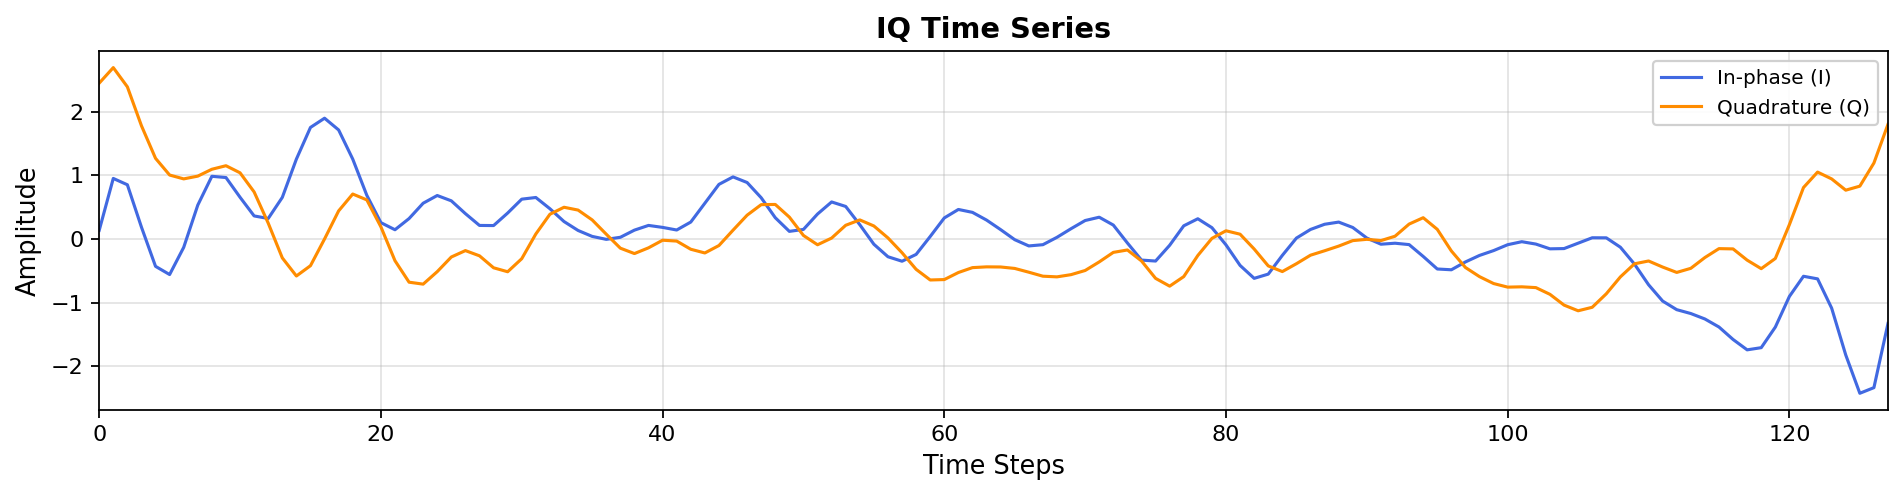

channel 0: corr(I, Q) = +0.028, corr(H(I), Q) = -0.557


In [9]:
sim = IQSimulator(mode="baseband", random_state=0)
sim.fit(channel_ri=channel)
iq_batch = sim.transform(seq_length=128, num_channels=2)
print("ARMA IQ batch:", iq_batch.shape)

iq0 = iq_batch[0]
plot_iq_series(iq0, overlay=True)
plt.show()
# plot_iq_series(iq0, overlay=False)
# plt.show()

corr_iq, corr_h = iq_correlations(iq0)
print(f"channel 0: corr(I, Q) = {corr_iq:+.3f}, corr(H(I), Q) = {corr_h:+.3f}")

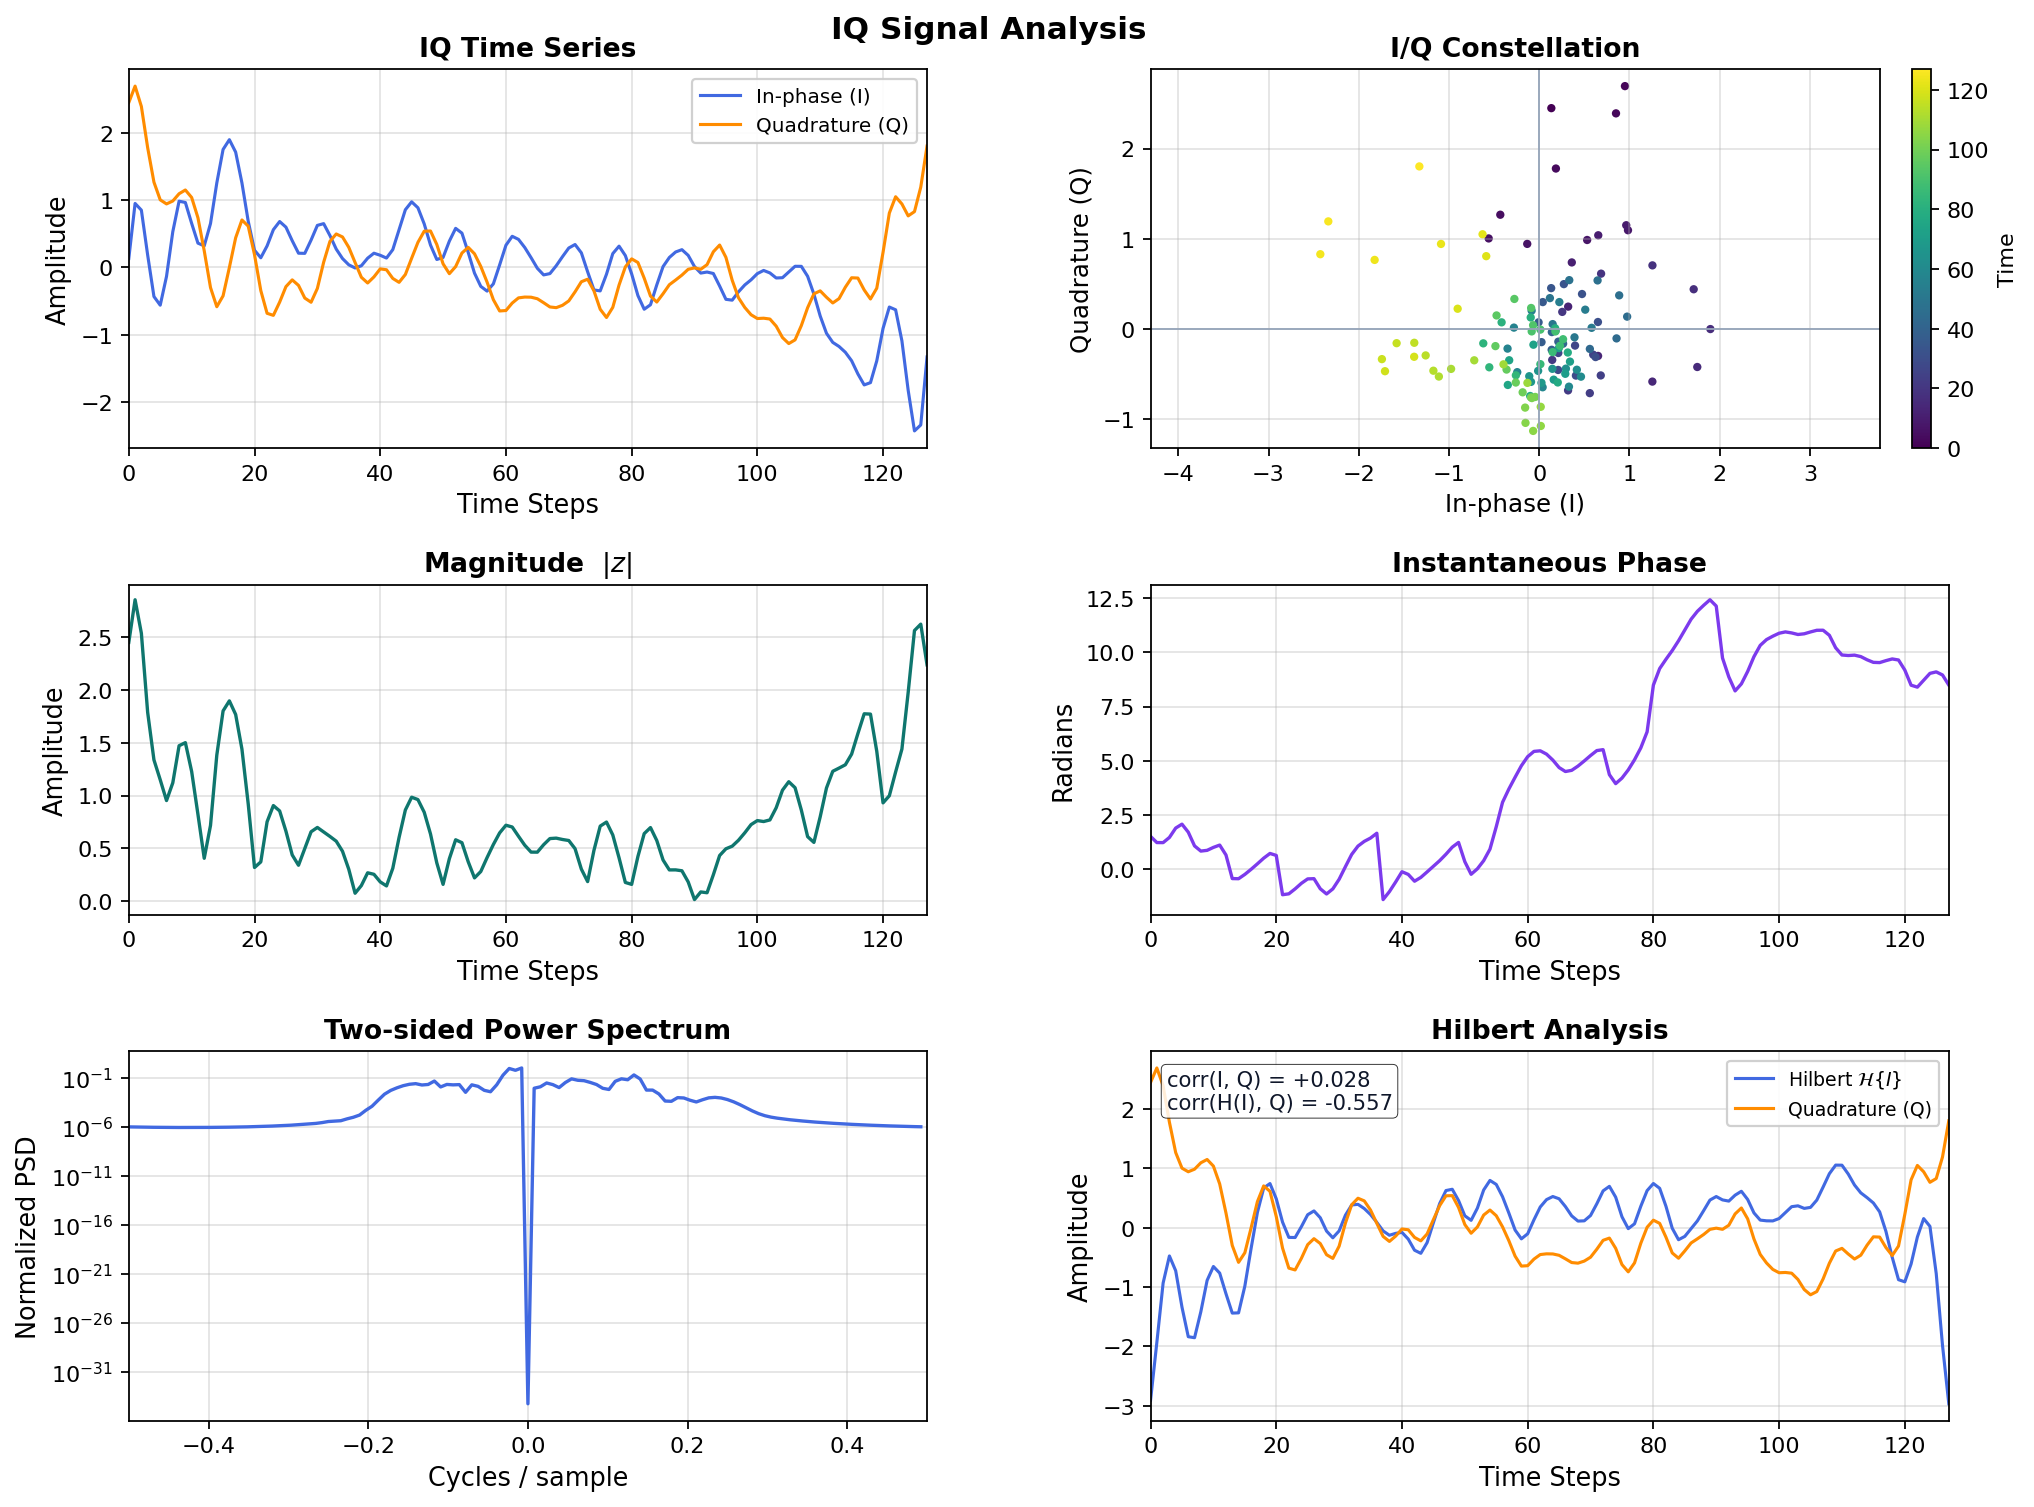

channel 1: corr(I, Q) = +0.039, corr(H(I), Q) = -0.563


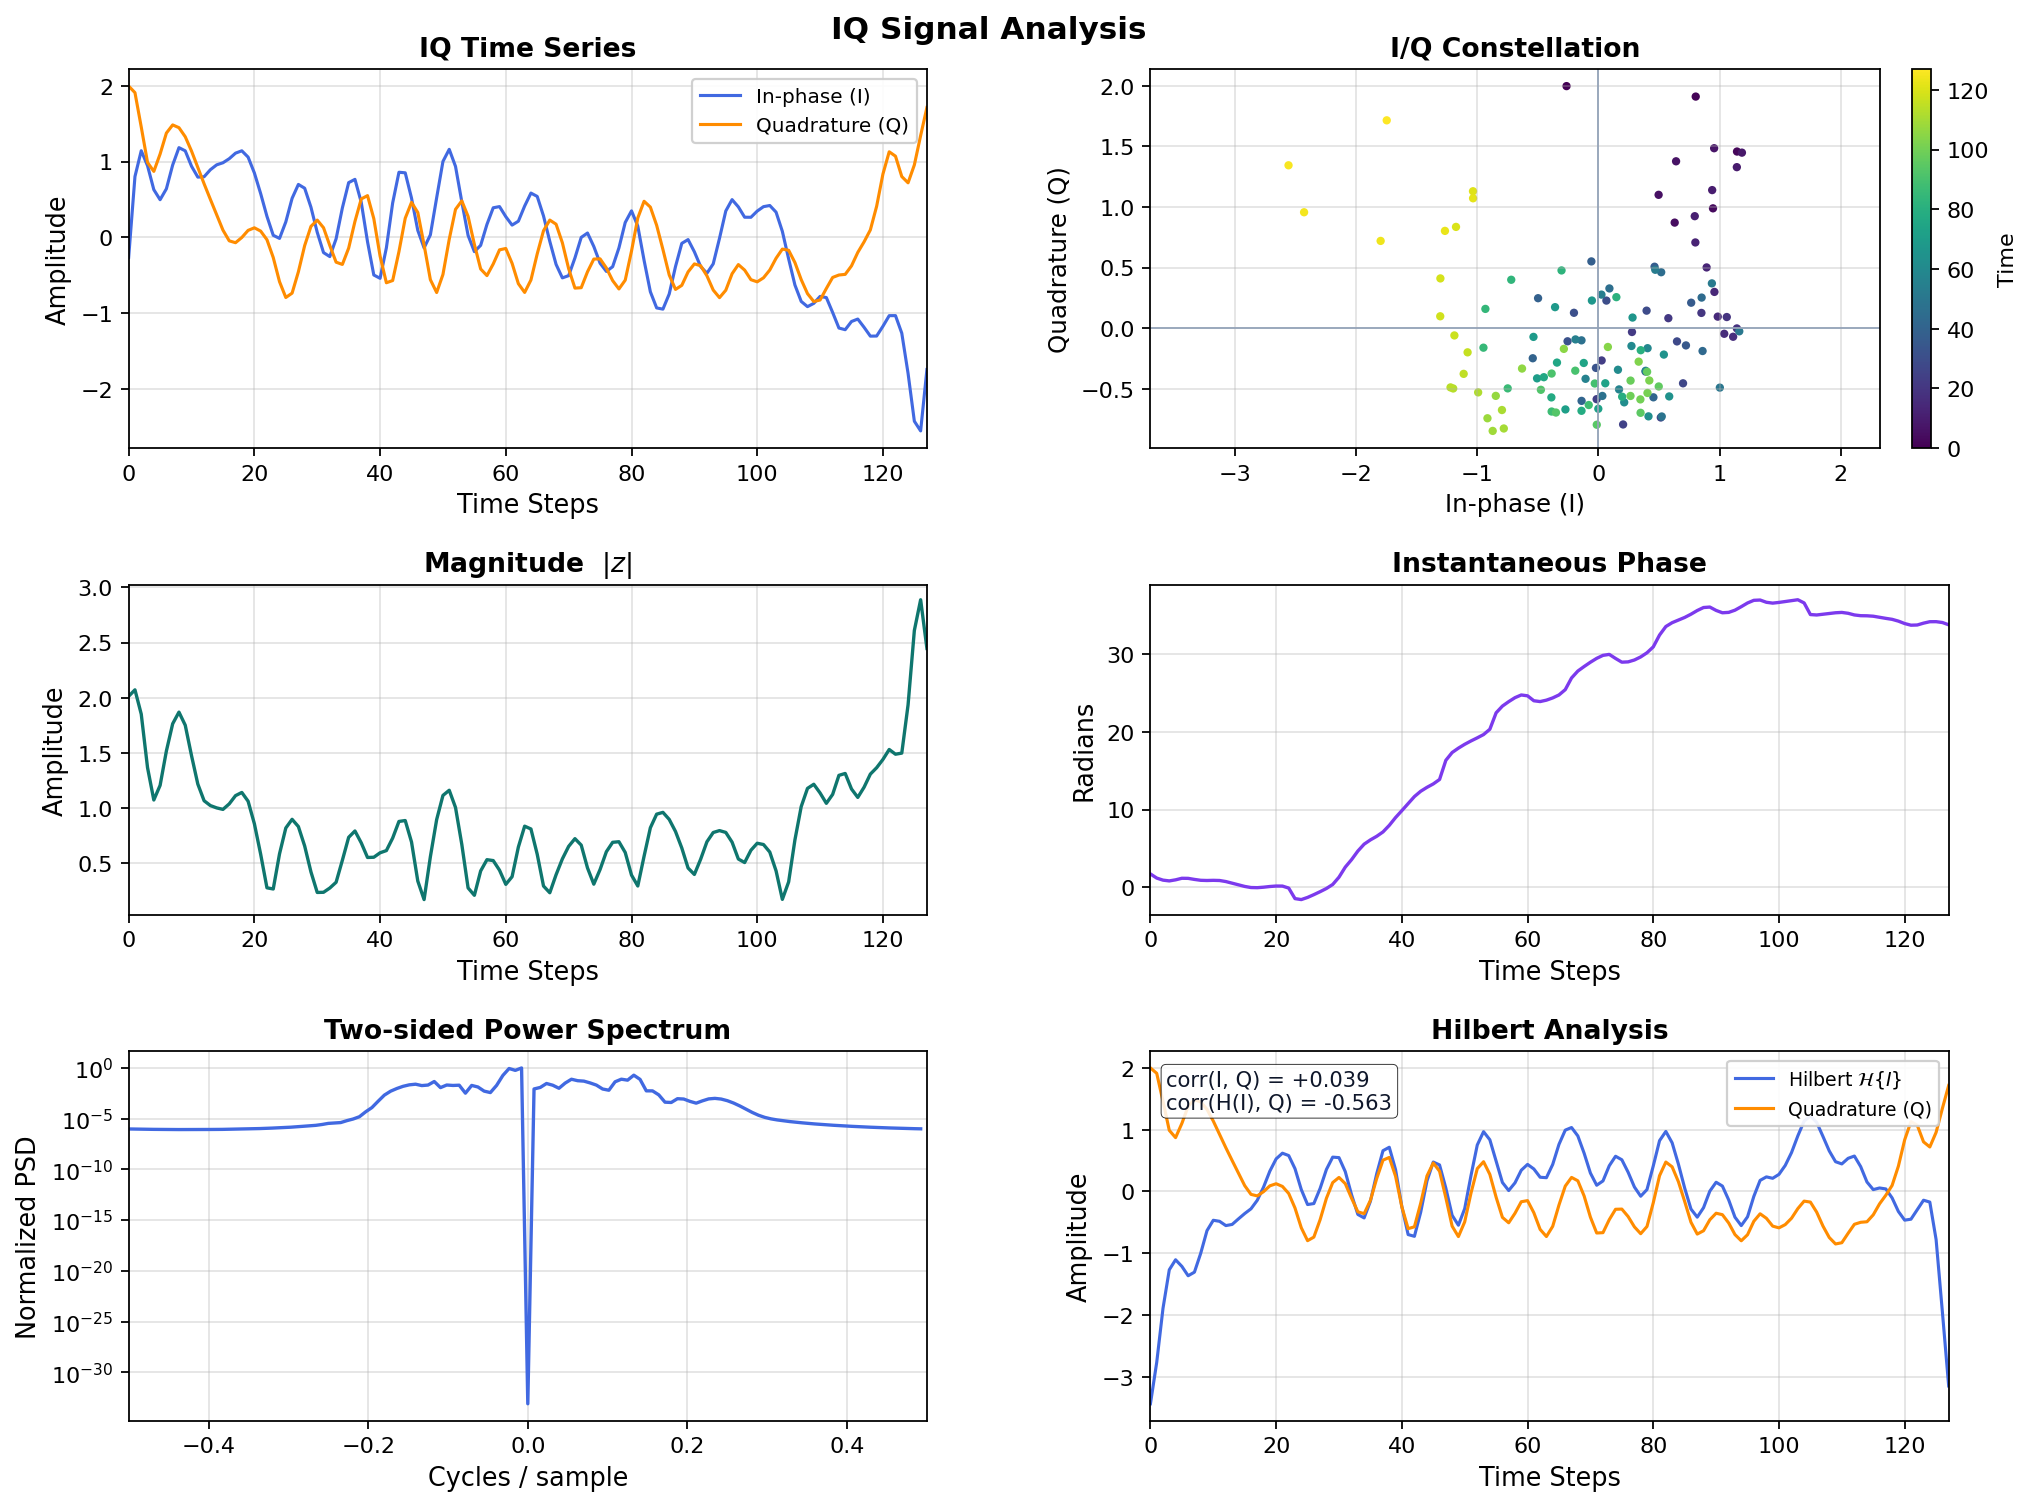

In [3]:
plot_iq_analysis(iq0, overlay=True)
plt.show()

corr_iq, corr_h = iq_correlations(iq_batch[1])
print(f"channel 1: corr(I, Q) = {corr_iq:+.3f}, corr(H(I), Q) = {corr_h:+.3f}")
plot_iq_analysis(iq_batch[1], overlay=True)
plt.show()

## User-provided stimulus

A damped oscillation is converted with the same fitted 40 km/h PSD. The envelope and instantaneous phase still come from the real series; the two-sided Doppler occupancy comes from the channel.

damped IQ: (2, 128)
corr(I, Q) = -0.069, corr(H(I), Q) = -0.556


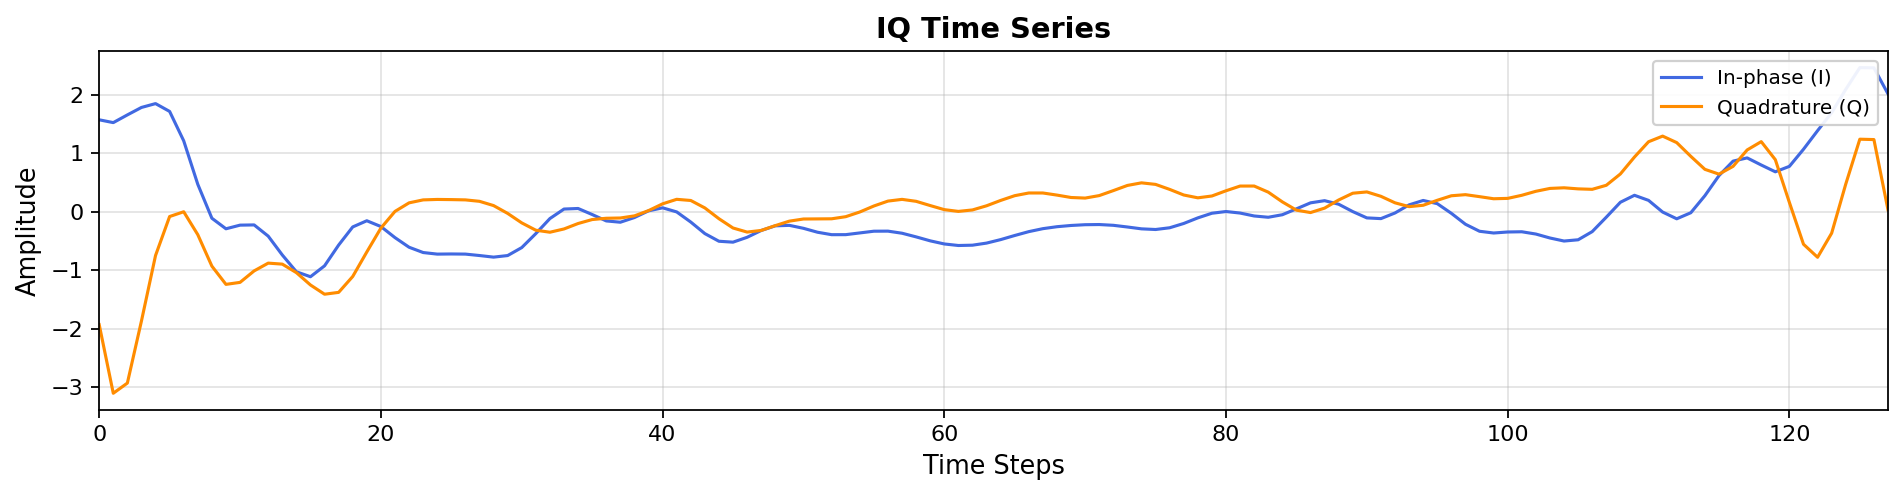

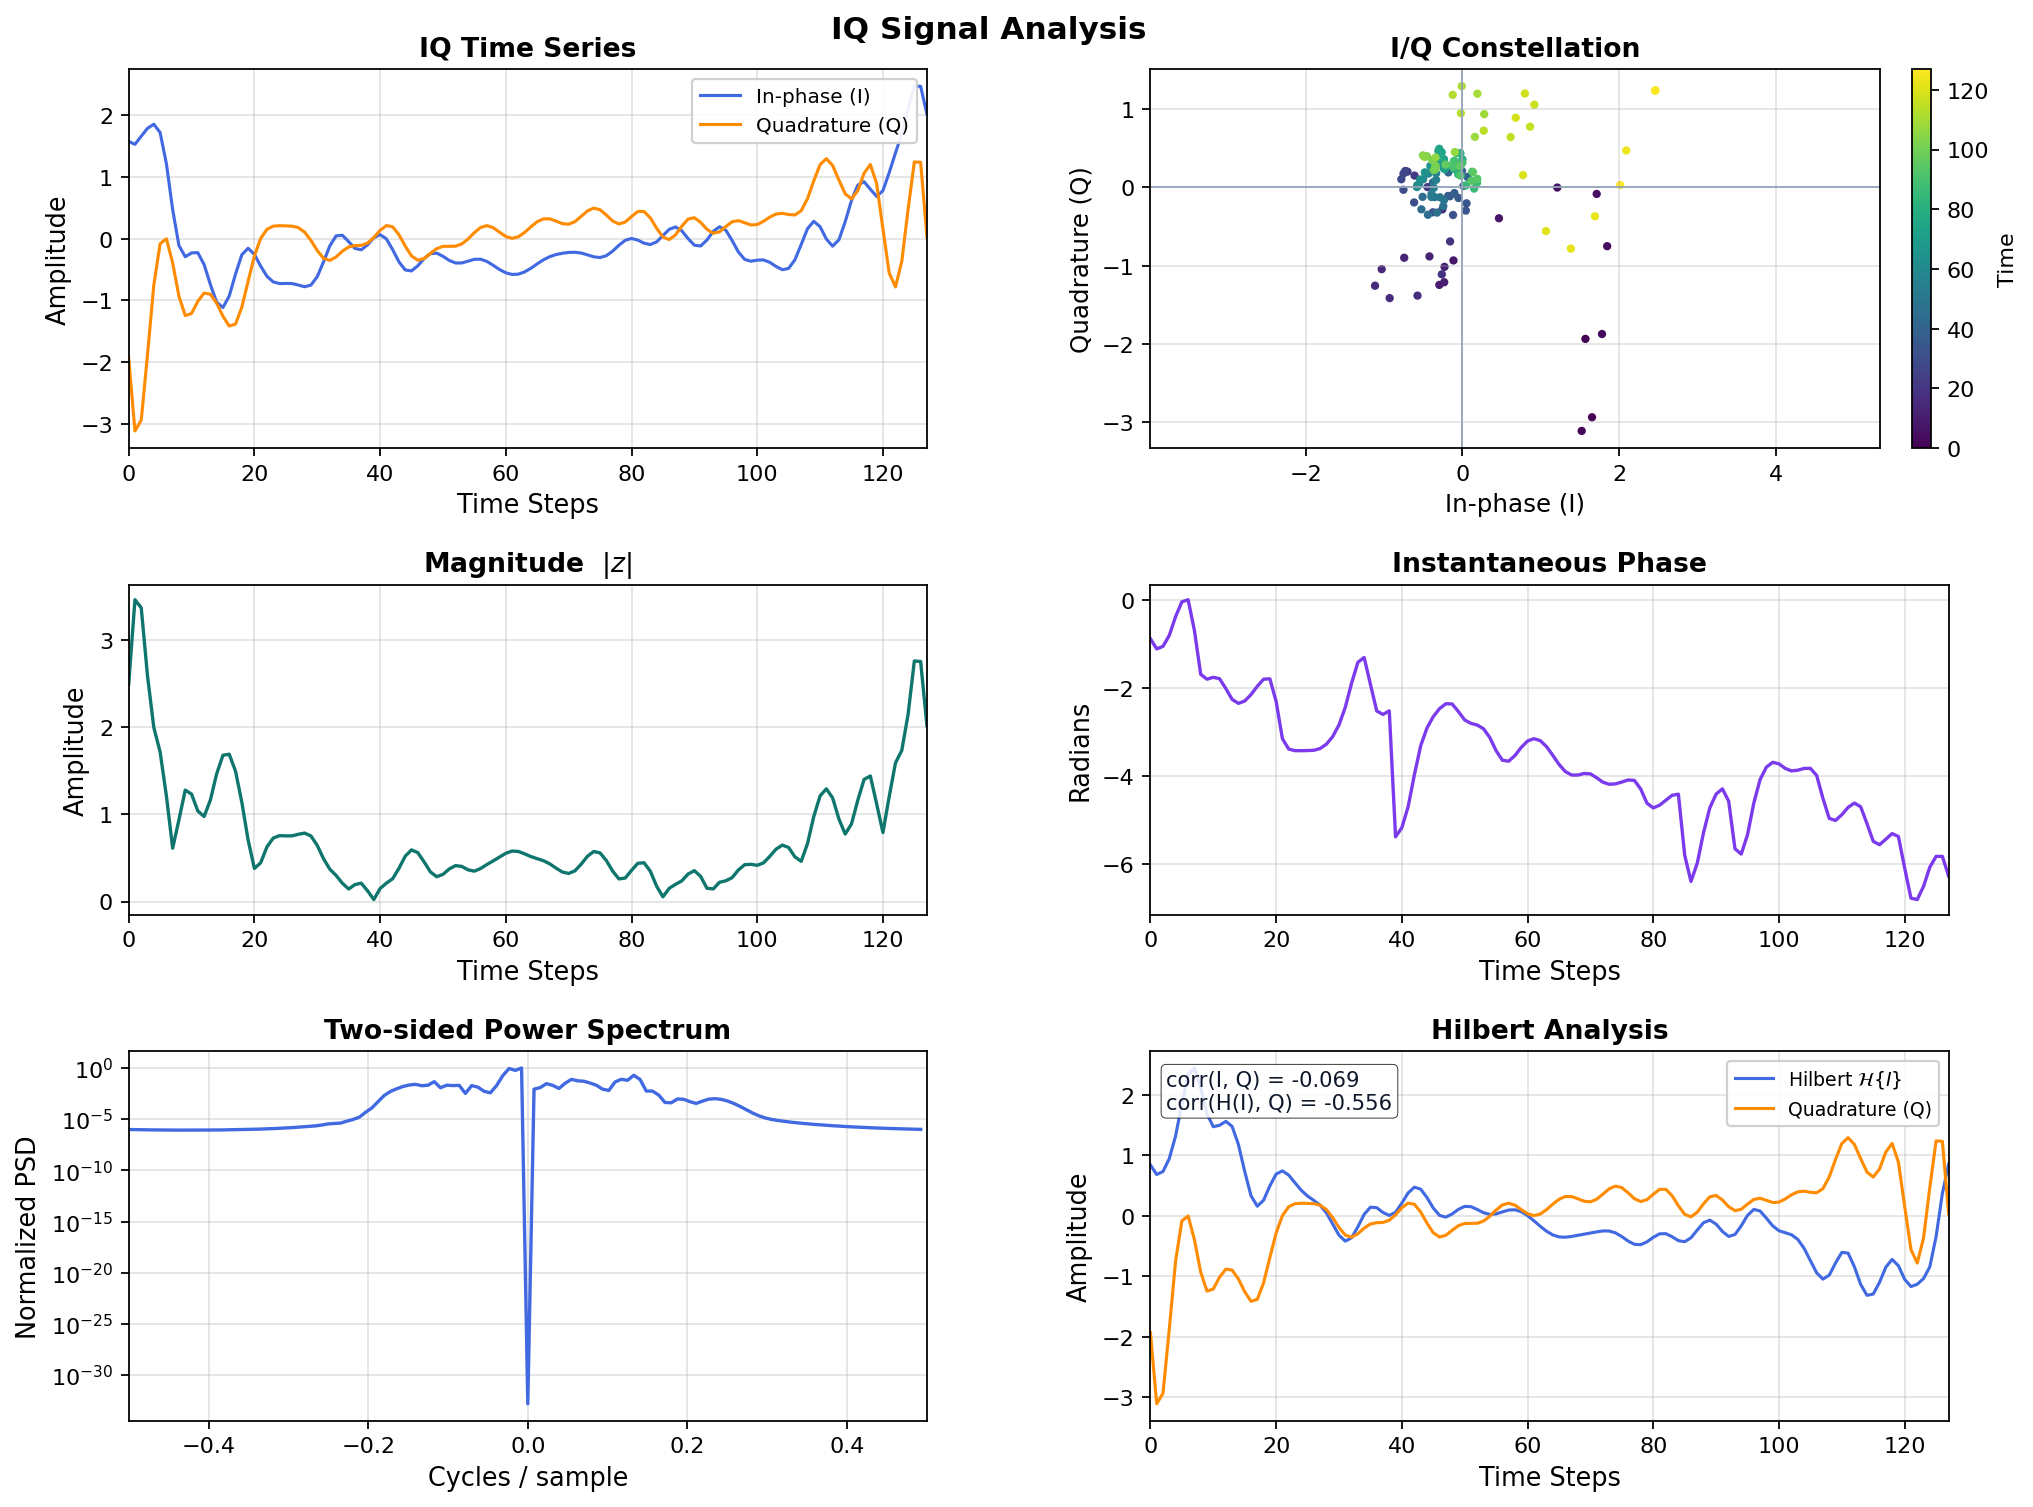

In [4]:
stimulus = generate_damped_oscillation(
    seq_length=256,
    freq=4.0,
    damping_factor=0.8,
    sample_rate=64.0,
    amp=1.0,
    noise_std=0.0,
)
iq_damped = sim.transform(time_series=stimulus, seq_length=128)
print("damped IQ:", iq_damped.shape)
corr_iq, corr_h = iq_correlations(iq_damped)
print(f"corr(I, Q) = {corr_iq:+.3f}, corr(H(I), Q) = {corr_h:+.3f}")

plot_iq_series(iq_damped, overlay=True)
plt.show()
plot_iq_analysis(iq_damped, overlay=True)
plt.show()

## Hyperparameters

### `mode`: baseband vs analytic

The same stimulus and the same CSI yield a two-sided fading pair or a one-sided analytic pair. Watch the Hilbert panel and the sign of the Doppler spectrum.

mode=baseband  corr(I, Q)=-0.069  corr(H(I), Q)=-0.556


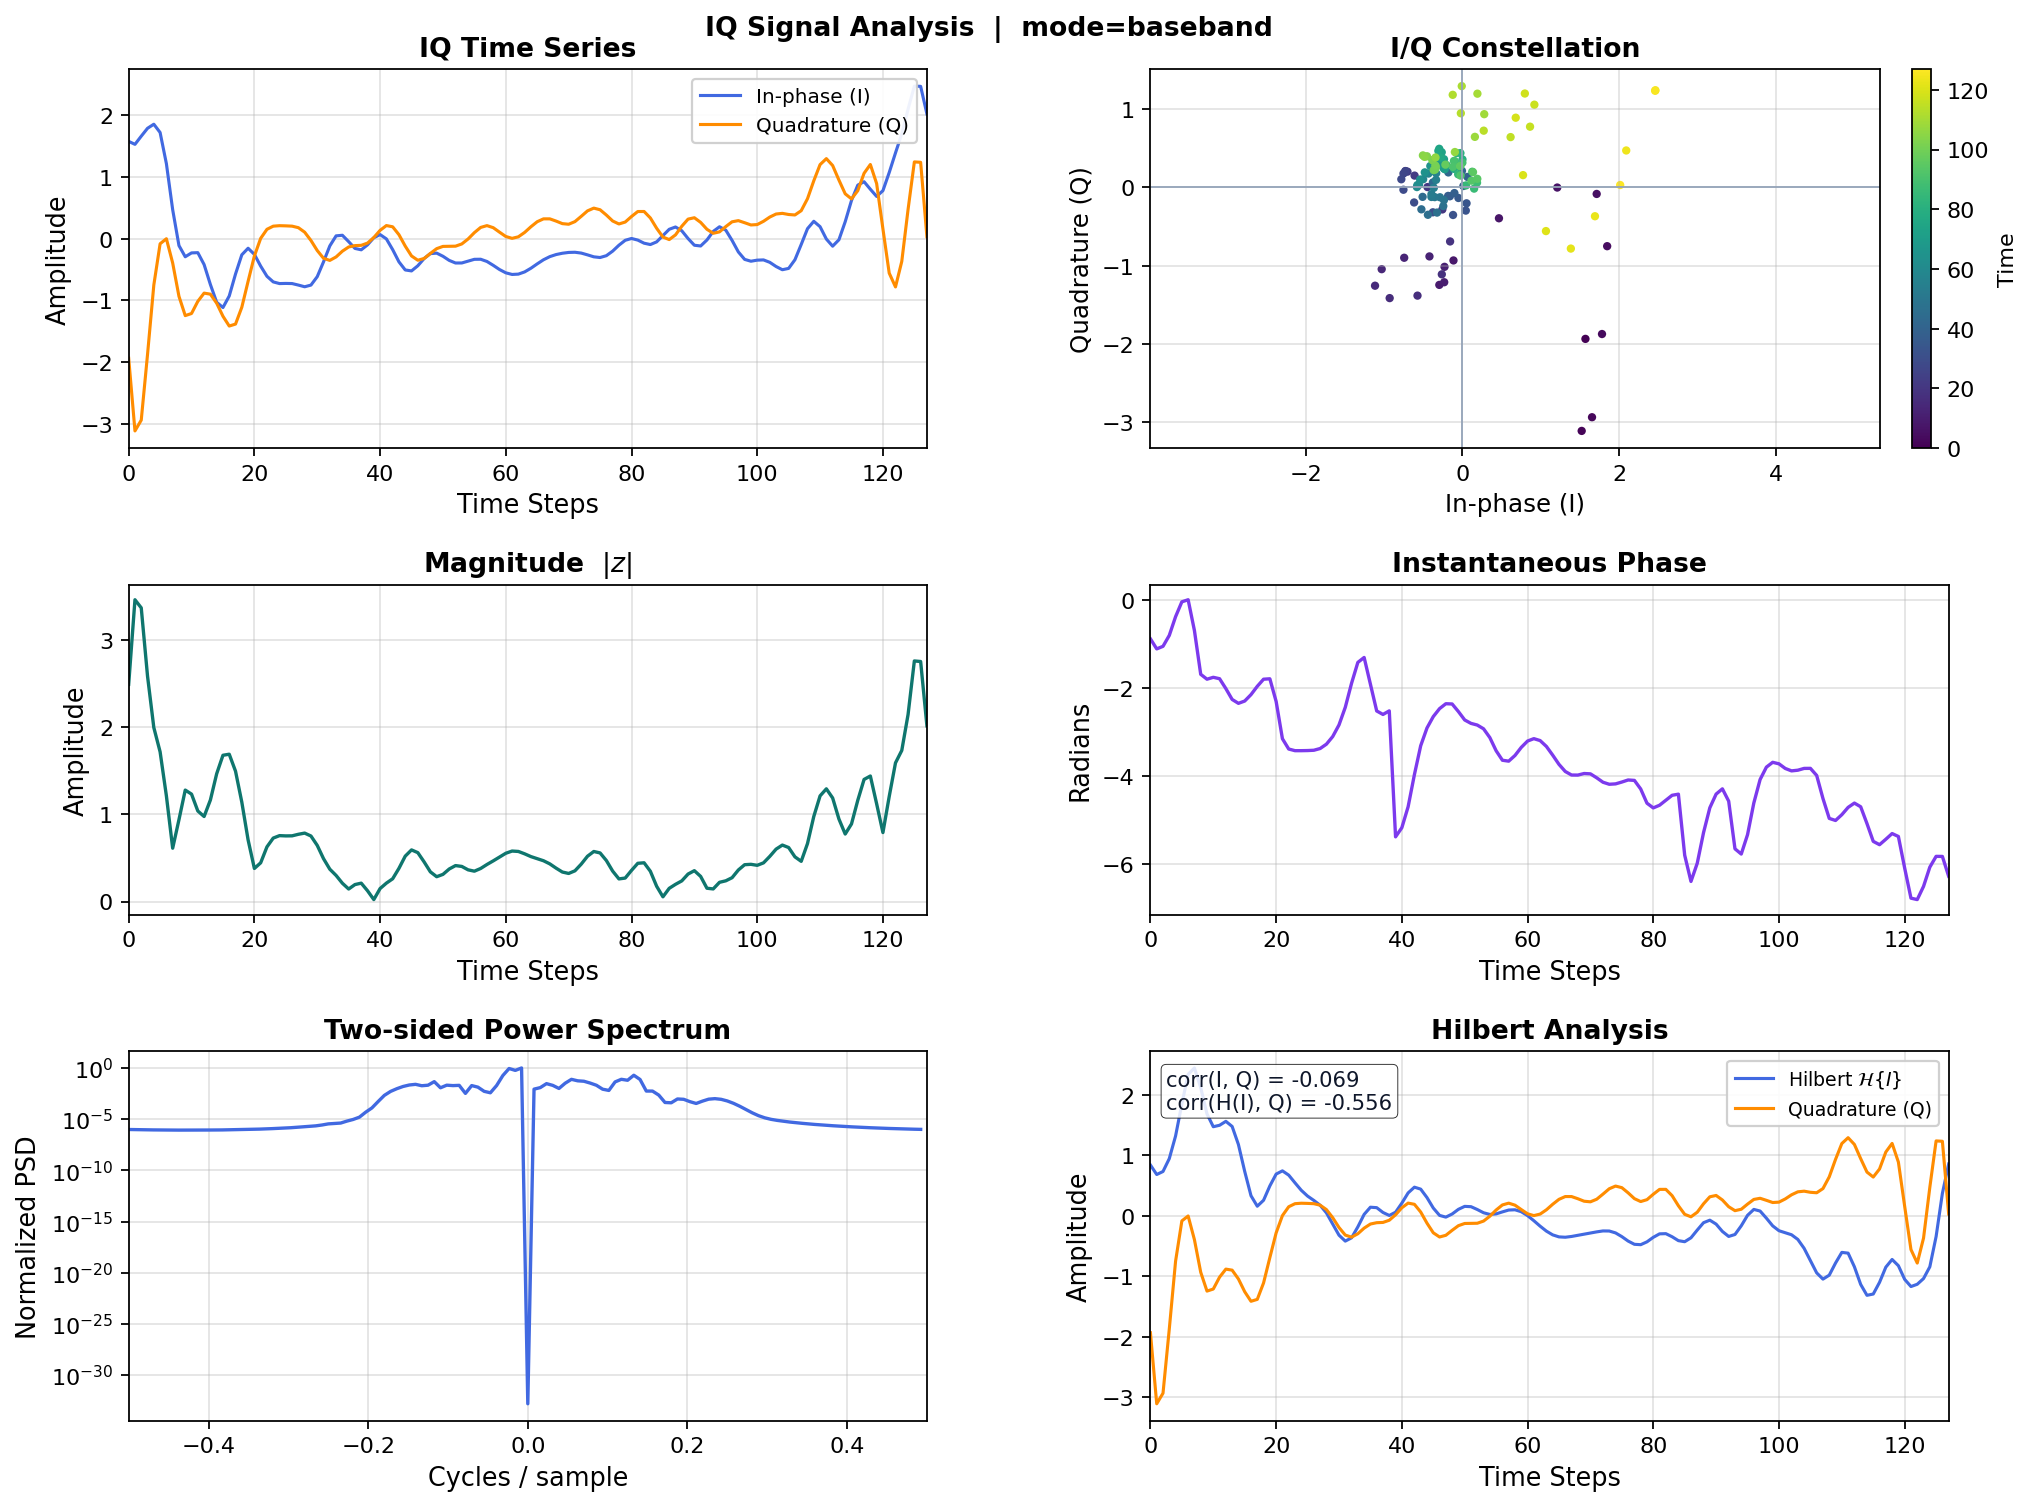

mode=analytic  corr(I, Q)=-0.000  corr(H(I), Q)=+1.000


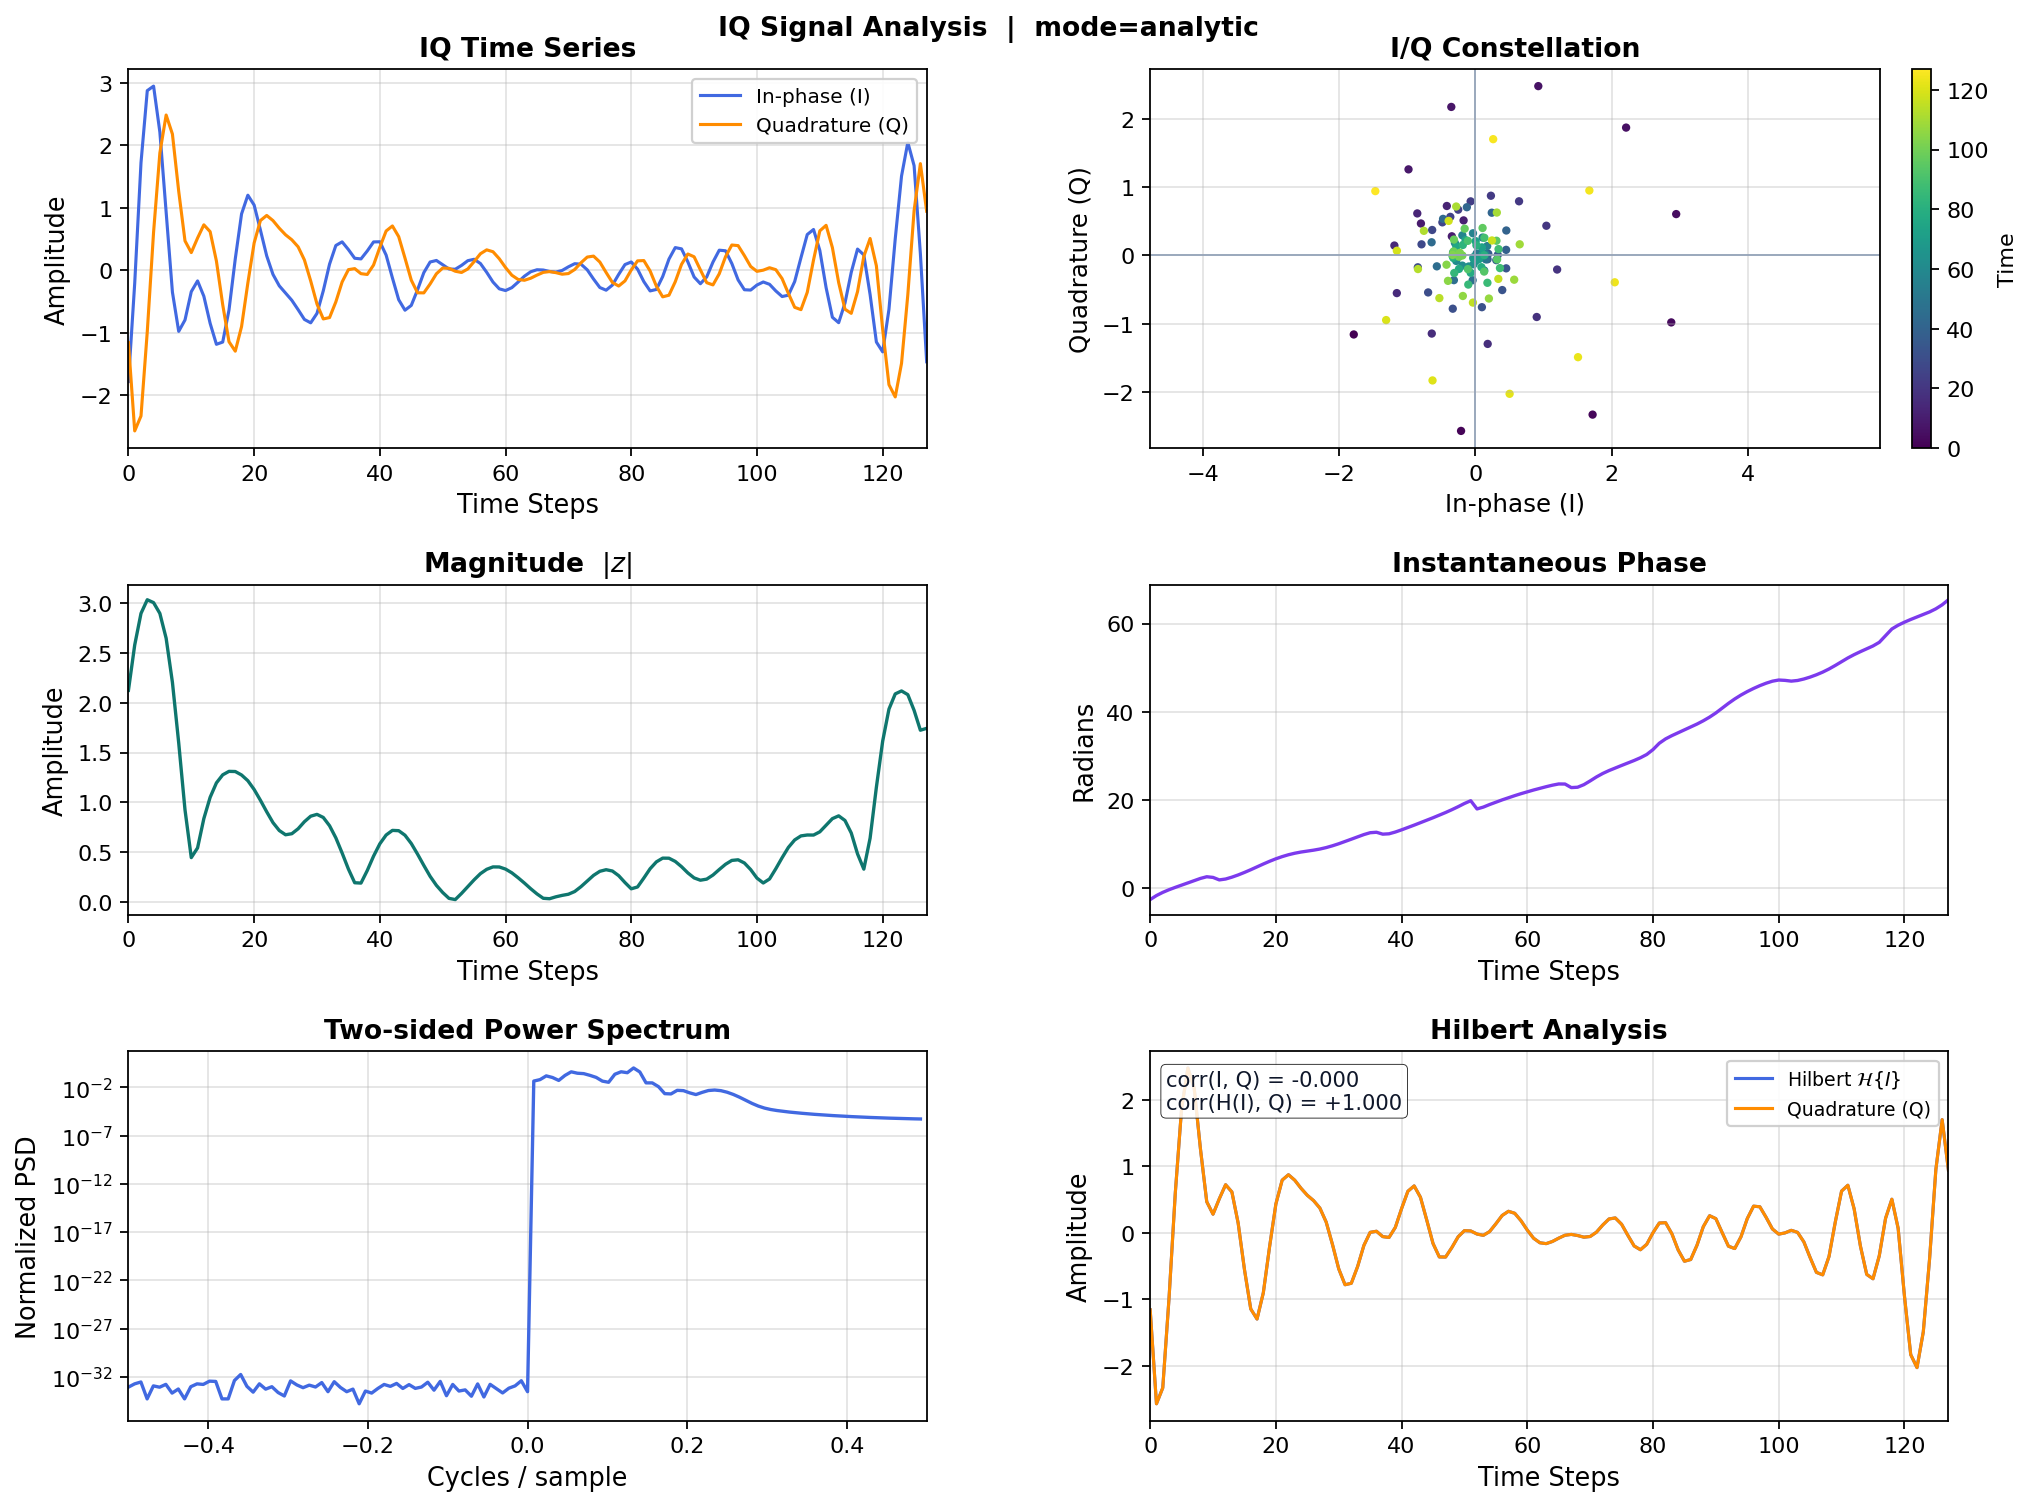

In [5]:
for mode in ("baseband", "analytic"):
    conv = IQSimulator(mode=mode, random_state=0).fit(channel_ri=channel)
    iq = conv.transform(time_series=stimulus, seq_length=128)
    corr_iq, corr_h = iq_correlations(iq)
    print(f"mode={mode:8s}  corr(I, Q)={corr_iq:+.3f}  corr(H(I), Q)={corr_h:+.3f}")
    plot_iq_analysis(iq, overlay=True)
    plt.suptitle(f"IQ Signal Analysis  |  mode={mode}", fontweight="bold", y=0.985)
    plt.show()

### `match_mix`: how hard the PSD is imposed

`match_mix=0` keeps the Hilbert-seed magnitudes (almost analytic). `match_mix=1` fully replaces them with $\sqrt{P[k]}$.

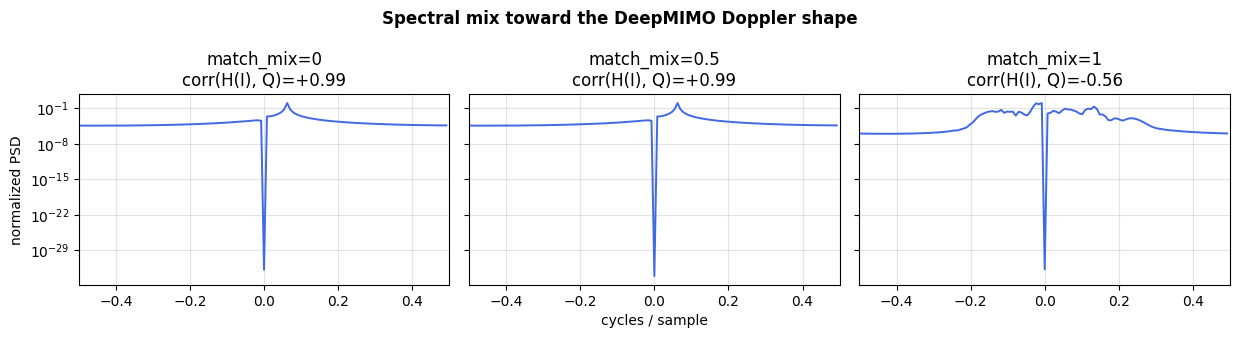

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4), sharey=True)
for ax, mix in zip(axes, (0.0, 0.5, 1.0)):
    conv = IQSimulator(match_mix=mix, random_state=0).fit(channel_ri=channel)
    iq = conv.transform(time_series=stimulus, seq_length=128)
    z = iq[0] + 1j * iq[1]
    psd = np.abs(fft(z - np.mean(z))) ** 2
    psd = fftshift(psd) / (psd.max() + 1e-18)
    freqs = fftshift(fftfreq(z.size))
    ax.semilogy(freqs, psd, color="royalblue", lw=1.4)
    corr_iq, corr_h = iq_correlations(iq)
    ax.set_title(f"match_mix={mix:g}\ncorr(H(I), Q)={corr_h:+.2f}")
    ax.set_xlim(-0.5, 0.5)
    ax.grid(True, which="both", alpha=0.35)
axes[0].set_ylabel("normalized PSD")
axes[1].set_xlabel("cycles / sample")
fig.suptitle("Spectral mix toward the DeepMIMO Doppler shape", fontweight="bold")
fig.tight_layout()
plt.show()

### Vehicle speed: Doppler occupancy

Faster trajectories in `city_37_seoul_3p5` spread energy over a wider two-sided Doppler band. Each speed uses the same damped stimulus so the comparison isolates $P[k]$.

 10 km/h  corr(I, Q)=-0.365  corr(H(I), Q)=-0.752  f_cut=0.039 cycles/sample
 40 km/h  corr(I, Q)=-0.069  corr(H(I), Q)=-0.556  f_cut=0.133 cycles/sample
100 km/h  corr(I, Q)=+0.082  corr(H(I), Q)=+0.925  f_cut=0.344 cycles/sample


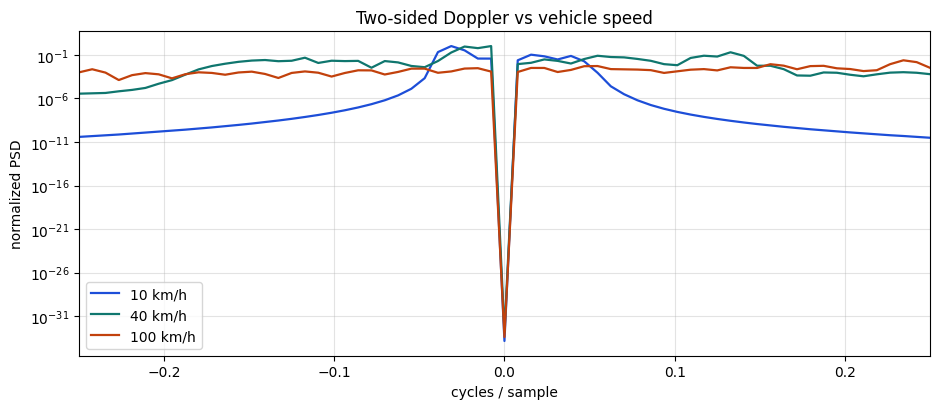

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for speed, color in ((10, "#1d4ed8"), (40, "#0f766e"), (100, "#c2410c")):
    traces = load_deepmimo_iq(speed_kmh=speed)
    conv = IQSimulator(mode="baseband", random_state=0).fit(channel_ri=traces)
    iq = conv.transform(time_series=stimulus, seq_length=128)
    z = iq[0] + 1j * iq[1]
    psd = np.abs(fft(z - np.mean(z))) ** 2
    psd = fftshift(psd) / (psd.max() + 1e-18)
    freqs = fftshift(fftfreq(z.size))
    ax.semilogy(freqs, psd, color=color, lw=1.6, label=f"{speed} km/h")
    corr_iq, corr_h = iq_correlations(iq)
    print(
        f"{speed:3d} km/h  corr(I, Q)={corr_iq:+.3f}  corr(H(I), Q)={corr_h:+.3f}  "
        f"f_cut={conv.f_cut_from_psd(conv.target_psd):.3f} cycles/sample"
    )
ax.set_xlim(-0.25, 0.25)
ax.set_xlabel("cycles / sample")
ax.set_ylabel("normalized PSD")
ax.set_title("Two-sided Doppler vs vehicle speed")
ax.legend()
ax.grid(True, which="both", alpha=0.35)
fig.tight_layout()
plt.show()

### Optional low-pass

With a fitted PSD the low-pass is off by default. Forcing `apply_lpf=True` smooths the stimulus *before* Hilbert and can trim high-frequency phase jitter, at the cost of a slightly rounder Doppler lobe.

apply_lpf=False  corr(I, Q)=-0.069  corr(H(I), Q)=-0.556


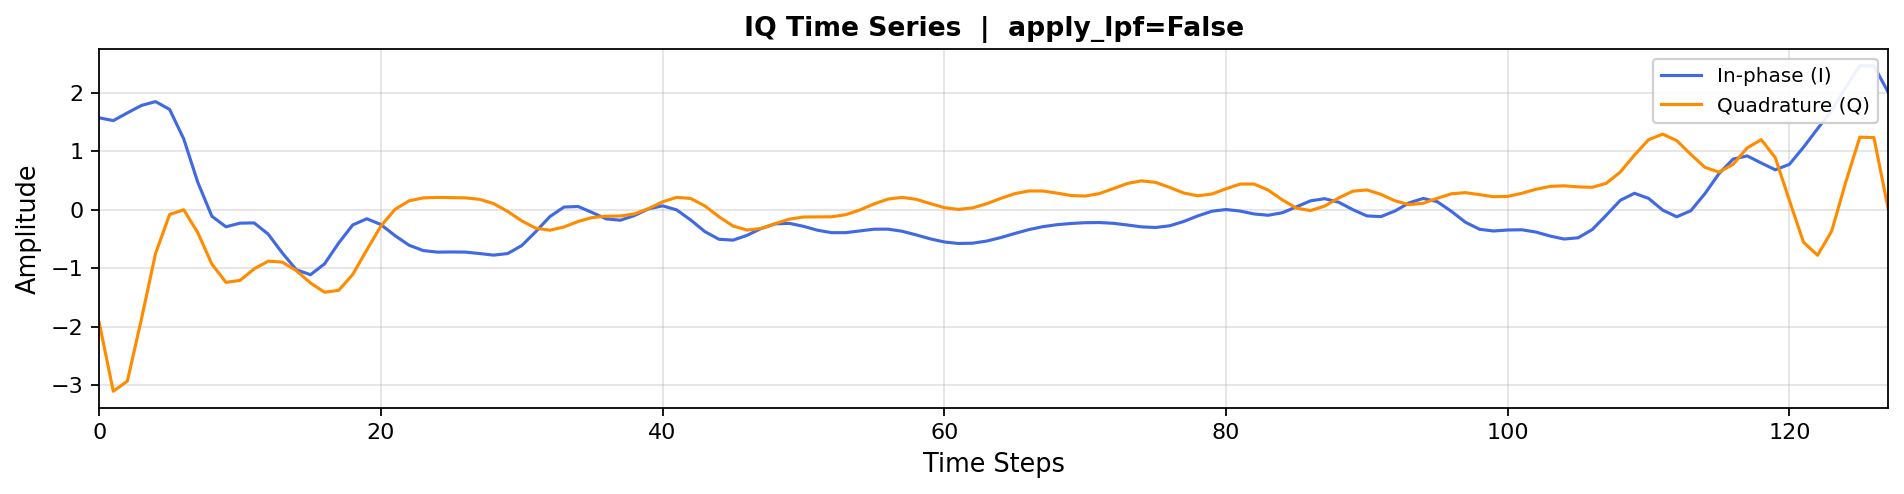

apply_lpf=True  corr(I, Q)=-0.069  corr(H(I), Q)=-0.556


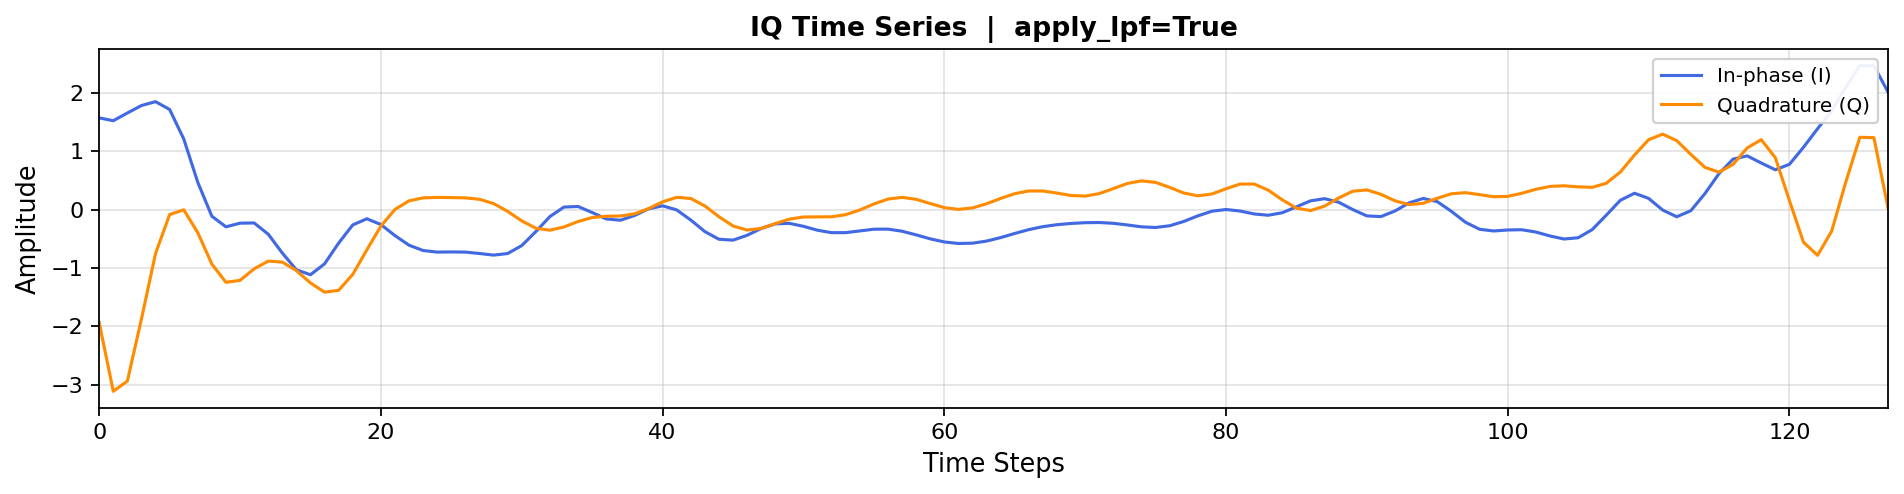

In [8]:
for apply_lpf in (False, True):
    conv = IQSimulator(apply_lpf=apply_lpf, random_state=0).fit(channel_ri=channel)
    iq = conv.transform(time_series=stimulus, seq_length=128)
    corr_iq, corr_h = iq_correlations(iq)
    print(
        f"apply_lpf={apply_lpf}  corr(I, Q)={corr_iq:+.3f}  corr(H(I), Q)={corr_h:+.3f}"
    )
    plot_iq_series(iq, overlay=True)
    plt.gca().set_title(f"IQ Time Series  |  apply_lpf={apply_lpf}", fontweight="bold")
    plt.show()

## Minimal usage

```python
from s2generator.simulator import IQSimulator
from s2generator.utils.data import load_deepmimo_iq
from s2generator.utils.visualization import plot_iq_analysis

channel = load_deepmimo_iq(speed_kmh=40)
sim = IQSimulator(mode="baseband", random_state=0)
sim.fit(channel_ri=channel)

# two ARMA-driven IQ pairs, shape [2, 2, 128]
iq_batch = sim.transform(seq_length=128)

# or convert a series you already have → shape [2, 128]
iq = sim.transform(time_series=x, seq_length=128)
plot_iq_analysis(iq)
```